# GoiEner EDA

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Carga de datos:

In [ ]:
metadata = pd.read_csv('metadata.csv')

print(f'Dimensiones: {metadata.shape[0]:,} filas x {metadata.shape[1]} columnas')
display(metadata.head())

Dimensiones: 25,559 filas x 23 columnas


,user,start_date,end_date,length_days,length_years,potential_samples,actual_samples,missing_samples_abs,missing_samples_pct,contract_start_date,...,p1,p2,p3,p4,p5,p6,province,municipality,zip_code,cnae
0,00000c5a448d9faa097b761cc98036d45a4e7d36032903...,2022-05-30T01:00:00Z,2022-06-05T00:00:00Z,6.0,0.016427,144,144,0,0.000000,2022-05-31,...,2.20,2.20,0.0,0.0,0.0,0.0,Gipuzkoa,NaN,NaN,9329.0
1,0001b3b2f18c01c62ed9b2a87de7b4e33e7836f786f790...,2017-05-31T01:00:00Z,2022-06-05T00:00:00Z,1831.0,5.013005,43944,43863,81,0.184326,2021-06-01,...,3.45,3.45,NaN,NaN,NaN,NaN,Bizkaia,NaN,NaN,9820.0
2,0003de2700e20a1681d69fe287441d9041407a7698d5c8...,2017-05-31T01:00:00Z,2019-11-14T00:00:00Z,897.0,2.455852,21528,21476,52,0.241546,2019-09-02,...,4.60,NaN,NaN,NaN,NaN,NaN,Gipuzkoa,Donostia/San Sebastian,20013.0,9820.0
3,0004150214d14a2b2e6f7075531e661cf465b27ec4d0d5...,2018-07-12T01:00:00Z,2022-06-05T00:00:00Z,1424.0,3.898700,34176,34169,7,0.020482,2021-06-01,...,9.20,9.20,NaN,NaN,NaN,NaN,Gipuzkoa,Irun,20304.0,4759.0
4,000721f0fc6ccf02ae24b67393979513171f2abc119af0...,2017-05-30T01:00:00Z,2022-06-04T00:00:00Z,1831.0,5.013005,43944,43815,129,0.293555,2021-06-01,...,4.40,4.40,NaN,NaN,NaN,NaN,Bizkaia,NaN,NaN,9820.0


In [ ]:
df = metadata.copy()

df['province_clean'] = (df['province'].fillna('Sin provincia')
                        .astype(str).str.strip())

df['municipality_clean'] = (df['municipality'].fillna('Sin municipio')
                            .astype(str).str.strip())

df['cnae_clean'] = pd.to_numeric(df['cnae'], errors='coerce').astype('Int64')

print(f"Usuarios únicos: {df['user'].nunique():,}")
print(f"Provincias: {df['province_clean'].nunique():,}")
print(f"Municipios: {df['municipality_clean'].nunique():,}")
print(f"CNAE distintos: {df['cnae_clean'].nunique(dropna=True):,}")

Usuarios únicos: 25,559
Provincias: 48
Municipios: 103
CNAE distintos: 341


Análisis por provincia:

In [ ]:
province_summary = (
    df.groupby("province_clean")
      .agg(
          n_users=("user", "count"),
          pct_users=("user", lambda x: len(x) / len(df) * 100),
          length_days_mean=("length_days", "mean"),
          length_days_median=("length_days", "median"),
          missing_pct_mean=("missing_samples_pct", "mean"),
          missing_pct_median=("missing_samples_pct", "median"),
          n_municipalities=("municipality_clean", "nunique"),
      )
      .sort_values("n_users", ascending=False)
      .reset_index()
)

display(province_summary.head(15).round(2))

,province_clean,n_users,pct_users,length_days_mean,length_days_median,missing_pct_mean,missing_pct_median,n_municipalities
0,Gipuzkoa,9291,36.35,1081.37,1068.04,0.46,0.02,3
1,Bizkaia,6446,25.22,1127.13,1222.00,0.57,0.03,4
2,Navarra,3497,13.68,997.03,1004.00,0.44,0.02,2
3,Araba/Alava,2649,10.36,1137.20,1248.00,0.36,0.03,2
4,Madrid,1110,4.34,767.44,688.50,0.82,0.02,24
5,Huelva,558,2.18,596.33,637.50,1.25,0.02,2
6,Soria,379,1.48,994.86,1115.00,0.94,0.02,1
7,Sin provincia,188,0.74,105.02,94.50,1.13,0.02,1
8,Cantabria,167,0.65,1103.99,1015.00,0.65,0.02,3
9,Valencia/Valencia,163,0.64,438.89,377.00,0.14,0.03,6


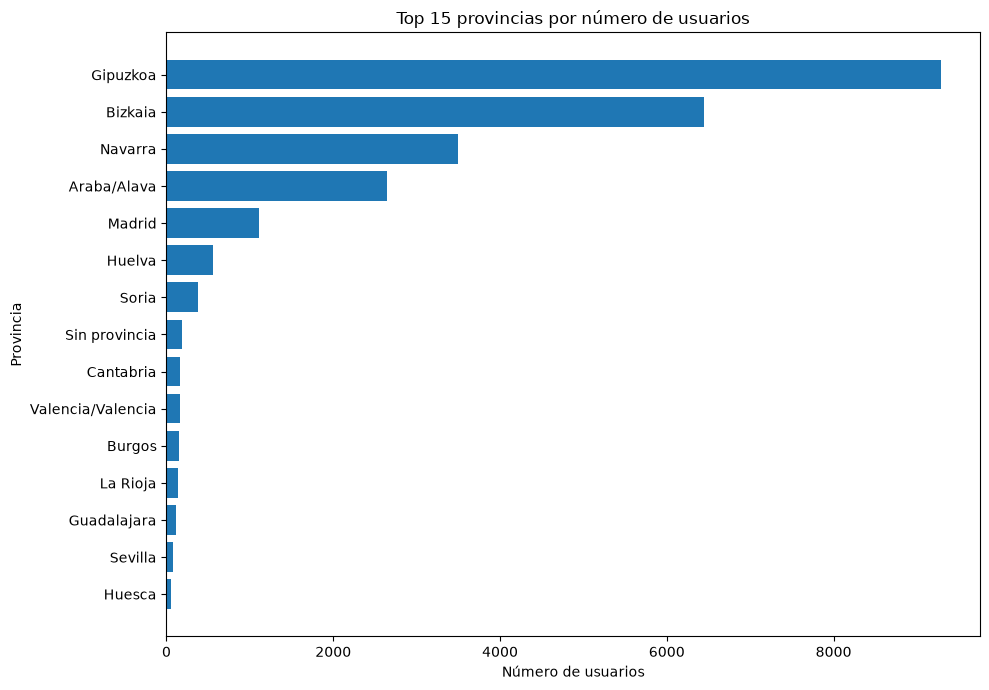

In [ ]:
top15 = province_summary.head(15).sort_values("n_users", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top15["province_clean"], top15["n_users"])
plt.xlabel("Número de usuarios")
plt.ylabel("Provincia")
plt.title("Top 15 provincias por número de usuarios")
plt.tight_layout()
plt.show()

Filtrar por Bilbao y CNAE 9820 (residencial):


In [ ]:
bilbao = df[df["municipality_clean"].str.casefold().eq("bilbao")].copy()

print(f"Usuarios/registros en Bilbao: {len(bilbao):,}")
print(f"Usuarios únicos en Bilbao: {bilbao['user'].nunique():,}")
print(f"CNAE distintos en Bilbao: {bilbao['cnae_clean'].nunique(dropna=True):,}")

cnae_counts = (bilbao["cnae_clean"].fillna(-1).value_counts().rename_axis("cnae").reset_index(name="n_users"))

cnae_counts["cnae_label"] = cnae_counts["cnae"].astype(str).replace("-1", "Sin CNAE")
cnae_counts["pct_users"] = cnae_counts["n_users"] / len(bilbao) * 100

display(cnae_counts.head(20))

Usuarios/registros en Bilbao: 2,067
Usuarios únicos en Bilbao: 2,067
CNAE distintos en Bilbao: 94


,cnae,n_users,cnae_label,pct_users
0,9820,1776,9820,85.921626
1,5210,27,5210,1.306241
2,9810,26,9810,1.257862
3,8559,19,8559,0.919207
4,9821,19,9821,0.919207
5,5630,15,5630,0.725689
6,4110,14,4110,0.67731
7,9499,8,9499,0.387034
8,3299,7,3299,0.338655
9,4719,7,4719,0.338655


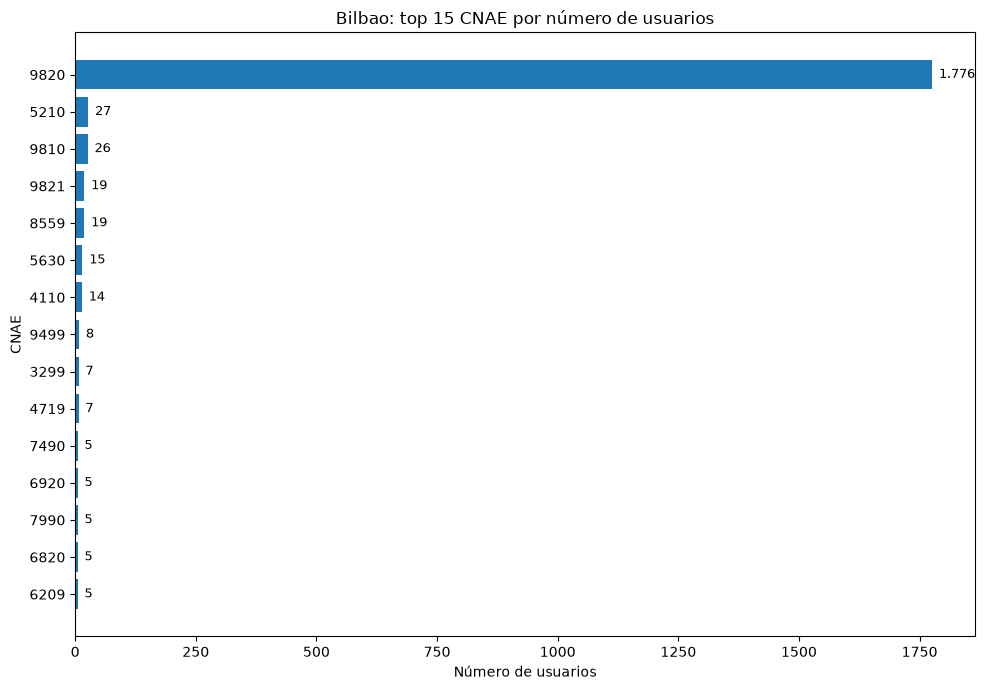

In [ ]:
top_cnae = cnae_counts.head(15).sort_values("n_users", ascending=True)

plt.figure(figsize=(10, 7))
bars = plt.barh(top_cnae["cnae_label"], top_cnae["n_users"])

plt.xlabel("Número de usuarios")
plt.ylabel("CNAE")
plt.title(f"Bilbao: top 15 CNAE por número de usuarios")

for bar, value in zip(bars, top_cnae["n_users"]):
    plt.text(
        bar.get_width() + max(top_cnae["n_users"]) * 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value):,}".replace(",", "."),
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

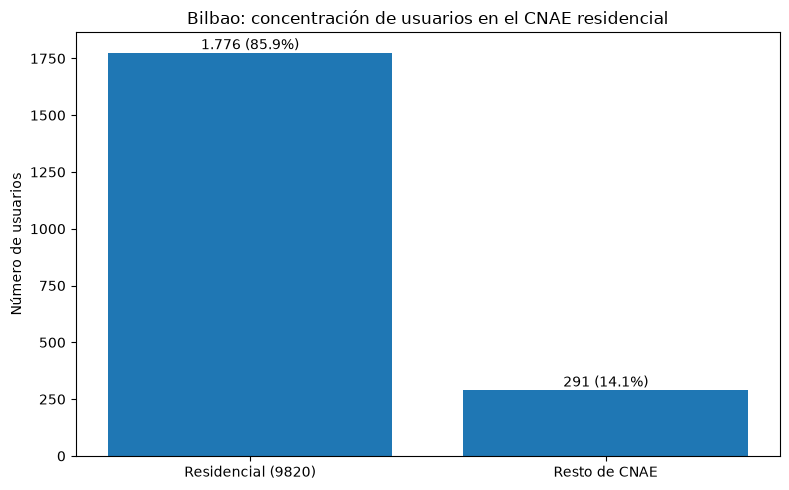

,grupo,n_users,pct_users
0,Residencial (9820),1776,85.92
1,Resto de CNAE,291,14.08


In [ ]:
bilbao["grupo_cnae"] = np.where(bilbao["cnae_clean"].eq(9820).fillna(False).to_numpy(),
                                "Residencial (9820)", "Resto de CNAE")

grupo_counts = (bilbao["grupo_cnae"].value_counts().rename_axis("grupo").reset_index(name="n_users"))

grupo_counts["pct_users"] = grupo_counts["n_users"] / len(bilbao) * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(grupo_counts["grupo"], grupo_counts["n_users"])

plt.ylabel("Número de usuarios")
plt.title("Bilbao: concentración de usuarios en el CNAE residencial")

for bar, n, pct in zip(bars, grupo_counts["n_users"], grupo_counts["pct_users"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(n):,} ({pct:.1f}%)".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

display(grupo_counts.round(2))

Filtro de cantidad de datos mínimo (al menos 3 año):

In [ ]:
bilbao_residencial = bilbao[bilbao["cnae_clean"].eq(9820)].copy()

model_users = bilbao_residencial[bilbao_residencial["length_days"] >= 1101].copy()

print(f"Bilbao total: {len(bilbao)} usuarios")
print(f"Bilbao CNAE {9820}: {len(bilbao_residencial)} usuarios")
print(f"Bilbao CNAE 9820 con > 3 años: {len(model_users)} usuarios")

selection_summary = pd.DataFrame({
    "métrica": [
        "Usuarios seleccionados",
        "Histórico medio (días)",
        "Histórico mediano (días)",
        "Datos perdidos medios (%)",
        "Datos perdidos medianos (%)",
        "Usuarios con <= 1% perdido (%)",
        "Usuarios con <= 5% perdido (%)",
    ],
    "valor": [
        len(model_users),
        model_users["length_days"].mean(),
        model_users["length_days"].median(),
        model_users["missing_samples_pct"].mean(),
        model_users["missing_samples_pct"].median(),
        (model_users["missing_samples_pct"] <= 1).mean() * 100,
        (model_users["missing_samples_pct"] <= 5).mean() * 100,
    ],
})

display(selection_summary.round(2))

Bilbao total: 2,067 usuarios
Bilbao CNAE 9820: 1,776 usuarios
Bilbao CNAE 9820 con > 3 años: 1,025 usuarios


,métrica,valor
0,Usuarios seleccionados,1025.00
1,Histórico medio (días),1673.55
2,Histórico mediano (días),1830.00
3,Datos perdidos medios (%),0.77
4,Datos perdidos medianos (%),0.13
5,Usuarios con <= 1% perdido (%),93.37
6,Usuarios con <= 5% perdido (%),97.76


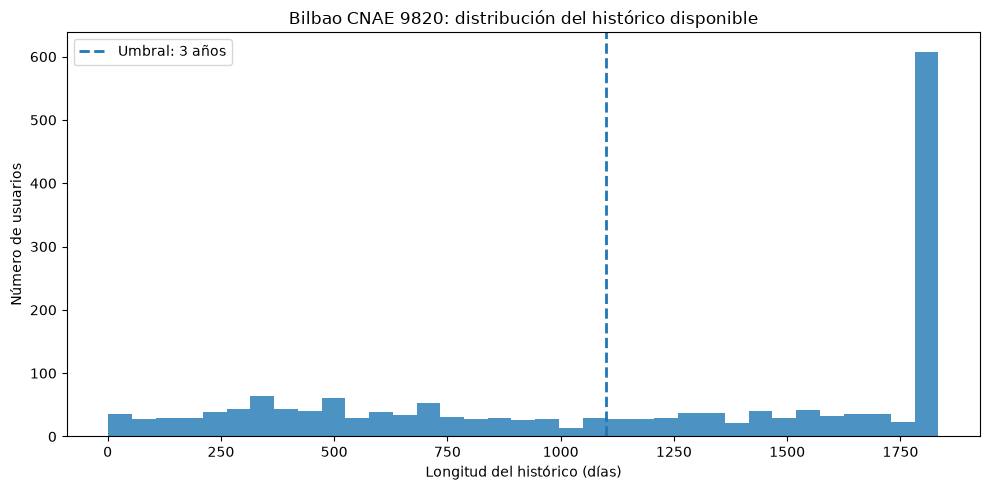

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(bilbao_residencial["length_days"].dropna(), bins=35, alpha=0.8)

plt.axvline(1101, linestyle="--", linewidth=2, label="Umbral: 3 años")

plt.xlabel("Longitud del histórico (días)")
plt.ylabel("Número de usuarios")
plt.title("Bilbao CNAE 9820: distribución del histórico disponible")
plt.legend()
plt.tight_layout()
plt.show()

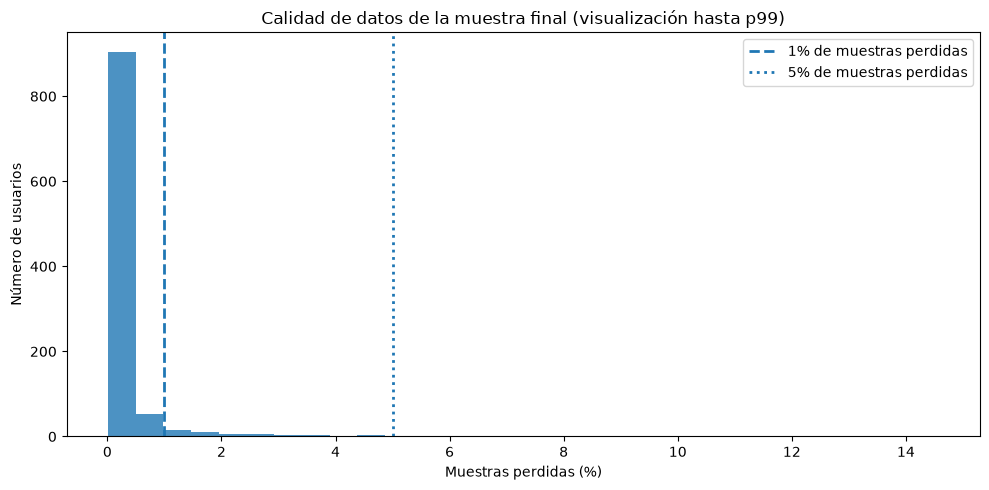

In [ ]:
missing_p99 = model_users["missing_samples_pct"].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(model_users.loc[model_users["missing_samples_pct"] <= missing_p99,
                         "missing_samples_pct"].dropna(), bins=30, alpha=0.8)

plt.axvline(1, linestyle="--", linewidth=2, label="1% de muestras perdidas")
plt.axvline(5, linestyle=":", linewidth=2, label="5% de muestras perdidas")

plt.xlabel("Muestras perdidas (%)")
plt.ylabel("Número de usuarios")
plt.title("Calidad de datos de la muestra final (visualización hasta p99)")
plt.legend()
plt.tight_layout()
plt.show()

Guardamos los usuarios que han pasado el filtro:

In [ ]:
filtro_bilb = df[df['province'].isin(['Bizkaia']) & df['municipality'].isin(['Bilbao']) & df['cnae'].isin([9820])
       & (df['length_days'] > 1100)]

filtro_bilb.to_csv('metadata_filtered.csv')